In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as StandardScaler

# Data Loading

In [2]:
spotify_df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv ')
spotify_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


# Initial Exploration

In [3]:
spotify_df.shape


(32833, 23)

32833 rows and 23 columns

Columns and their data types.

In [4]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [5]:
spotify_df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

track_name, track_artist, and track_album_name all have 5 missing values.

In [6]:
spotify_df.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

In [7]:
spotify_df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


# Treatment of Variables

The variables not useful for visualization are track_id, track_album_id, and playlist_id

The continuous variables I'll focus on are danceability, loudness and energy. I will convert tempo and valence into categorical variables.

The categorial variables I will focus on will be playlist_genre, subgenre, and mode.

I'm going to convert tempo and valence into categorial variables

# Summary Statistics

In [8]:
spotify_df['playlist_genre'].nunique()

6

In [9]:
spotify_df['playlist_subgenre'].nunique()

24

In [10]:
spotify_df['mode'].nunique()

2

In [11]:
spotify_df['energy'].describe()

count    32833.000000
mean         0.698619
std          0.180910
min          0.000175
25%          0.581000
50%          0.721000
75%          0.840000
max          1.000000
Name: energy, dtype: float64

In [12]:
spotify_df['tempo'].describe()

count    32833.000000
mean       120.881132
std         26.903624
min          0.000000
25%         99.960000
50%        121.984000
75%        133.918000
max        239.440000
Name: tempo, dtype: float64

In [13]:
spotify_df['mode'].describe()

count    32833.000000
mean         0.565711
std          0.495671
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: mode, dtype: float64

# Removing the Track Popularity variable after transforming into track_popularity_transformed

In [14]:
spotify_df['track_popularity_shifted'] = np.where(spotify_df.track_popularity == 100, spotify_df.track_popularity - 0.1, spotify_df.track_popularity)
spotify_df['track_popularity_shifted'] = np.where(spotify_df.track_popularity == 0, spotify_df.track_popularity + 0.1, spotify_df.track_popularity_shifted)

spotify_df['track_popularity_fraction'] = spotify_df.track_popularity_shifted/100

spotify_df['track_popularity_transformed'] = np.log(spotify_df.track_popularity_fraction / (1 - spotify_df.track_popularity_fraction))



In [15]:
spotify_df['track_popularity_transformed']

0        0.663294
1        0.708185
2        0.847298
3        0.405465
4        0.800119
           ...   
32828   -0.322773
32829   -1.386294
32830   -1.815290
32831   -1.734601
32832   -0.994623
Name: track_popularity_transformed, Length: 32833, dtype: float64

In [16]:
spotify_df.drop(columns=['track_popularity', 'track_popularity_shifted', 'track_popularity_fraction'], inplace=True)

In [17]:
spotify_df

,track_id,track_name,track_artist,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity_transformed
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754,0.663294
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600,0.708185
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616,0.847298
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093,0.405465
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,...,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052,0.800119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,progressive electro house,...,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375,-0.322773
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,progressive electro house,...,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120,-1.386294
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,progressive electro house,...,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112,-1.815290
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,progressive electro house,...,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432,-1.734601


In [18]:
spotify_df['track_popularity_transformed'].describe()

count    32833.000000
mean        -0.827397
std          2.212342
min         -6.906755
25%         -1.152680
50%         -0.200671
75%          0.489548
max          6.906755
Name: track_popularity_transformed, dtype: float64

In [19]:
spotify_df['tempo'].describe()

count    32833.000000
mean       120.881132
std         26.903624
min          0.000000
25%         99.960000
50%        121.984000
75%        133.918000
max        239.440000
Name: tempo, dtype: float64

In [20]:
spotify_df['danceability'].describe()

count    32833.000000
mean         0.654850
std          0.145085
min          0.000000
25%          0.563000
50%          0.672000
75%          0.761000
max          0.983000
Name: danceability, dtype: float64

# Converting Tempo and Mood(Valence) into Categorical Variables.

In [21]:
tempo_bins = [0, 90, 120, 150, 300]
tempo_labels =['slow', 'moderate', 'fast', 'very fast']
spotify_df['tempo_categorical'] = pd.cut(spotify_df['tempo'], bins=tempo_bins, labels=tempo_labels, include_lowest=True)

In [22]:
spotify_df['tempo_categorical']

0            fast
1        moderate
2            fast
3            fast
4            fast
           ...   
32828        fast
32829        fast
32830        fast
32831        fast
32832        fast
Name: tempo_categorical, Length: 32833, dtype: category
Categories (4, object): ['slow' < 'moderate' < 'fast' < 'very fast']

In [23]:
spotify_df[['tempo', 'tempo_categorical']]

,tempo,tempo_categorical
0,122.036,fast
1,99.972,moderate
2,124.008,fast
3,121.956,fast
4,123.976,fast
...,...,...
32828,128.170,fast
32829,128.041,fast
32830,127.989,fast
32831,128.008,fast


In [24]:
bins = [0.0, 0.5, 0.7, 0.9]
labels= ['Negative', 'Neutral', 'Positive']

spotify_df['valence_cat'] = pd.cut(spotify_df['valence'], bins=bins, labels=labels)

Comparing Categorial Valence and Valence for readability

In [25]:
spotify_df[['valence_cat', 'valence']]

,valence_cat,valence
0,Neutral,0.5180
1,Neutral,0.6930
2,Neutral,0.6130
3,Negative,0.2770
4,Positive,0.7250
...,...,...
32828,Negative,0.2100
32829,Negative,0.4000
32830,Negative,0.4360
32831,Negative,0.3080


Plotting track_popularity_transformed

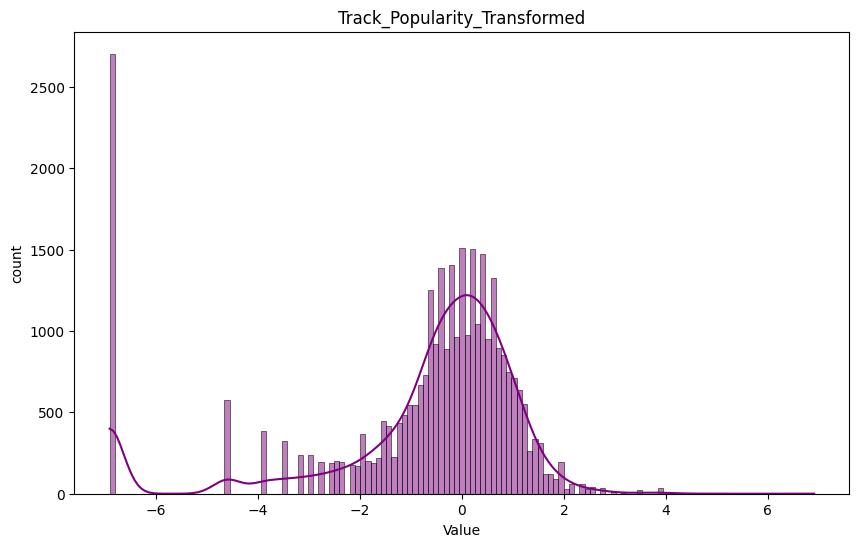

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(data=spotify_df, x='track_popularity_transformed', kde=True, color='purple')
plt.title('Track_Popularity_Transformed')
plt.xlabel('Value')
plt.ylabel('count')
plt.show()

For this graph, there is a sharp spike at the -7 value, and there are smaller spikes around the -4 and -3 values, the bell curve is mostly concentrated between -2 to 2

# Marginal Distributions

Categorical plots

C:\Users\Lyn\AppData\Local\Temp\ipykernel_10436\4006887955.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=spotify_df, x='tempo_categorical', palette='viridis')


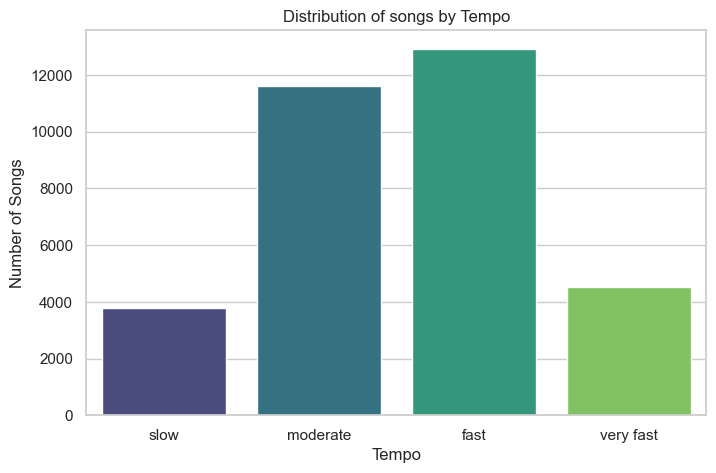

In [27]:
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')

sns.countplot(data=spotify_df, x='tempo_categorical', palette='viridis')

plt.title('Distribution of songs by Tempo')
plt.xlabel('Tempo')
plt.ylabel('Number of Songs')
plt.show()

The above graph shows that most songs in this dataset have a moderate to fast tempo.

C:\Users\Lyn\AppData\Local\Temp\ipykernel_10436\820280990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=spotify_df, x='valence_cat', palette='viridis')


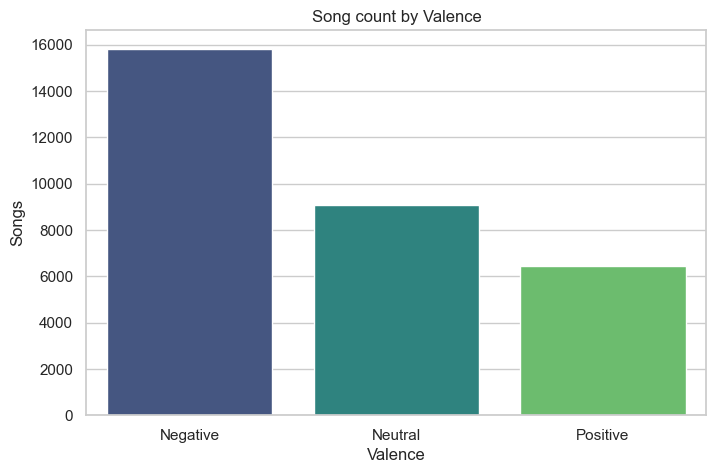

In [28]:
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')

sns.countplot(data=spotify_df, x='valence_cat', palette='viridis')

plt.title('Song count by Valence')
plt.xlabel('Valence')
plt.ylabel('Songs')
plt.show()

According to the above graph, most of the songs in this data set have a low/negative valence, which could mean this dataset is biased.

C:\Users\Lyn\AppData\Local\Temp\ipykernel_10436\3254825556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=spotify_df, x='playlist_genre', palette='viridis')


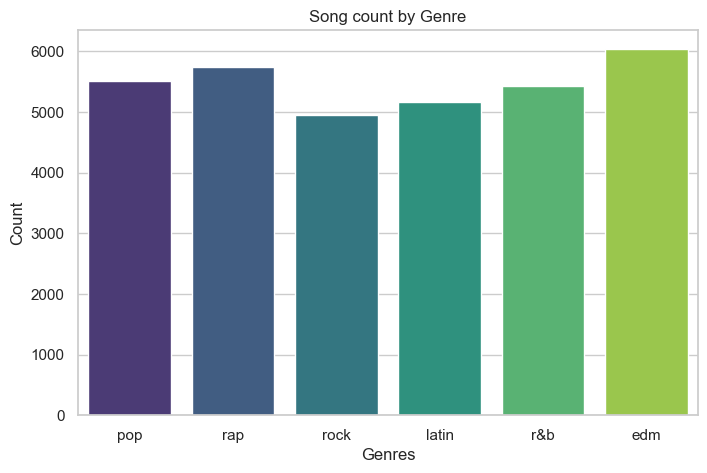

In [29]:
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')

sns.countplot(data=spotify_df, x='playlist_genre', palette='viridis')

plt.title('Song count by Genre')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

According to the above graph, the highest song counts of are the EDM (at 6000), and rap (around 5500?) genres.

# Continous Plots

Plotting Danceability

<Axes: xlabel='danceability', ylabel='Count'>

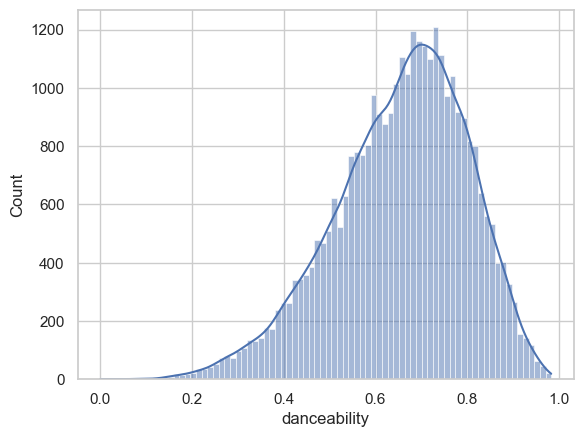

In [30]:
sns.histplot(data=spotify_df, x="danceability", kde=True)

This graph shows that the highest danceabililty concentration is between 0.6 and 0.8, and it starts to rise at 0.4. Meaning that this dataset consists of mostly mid to high danceability tracks.

Energy

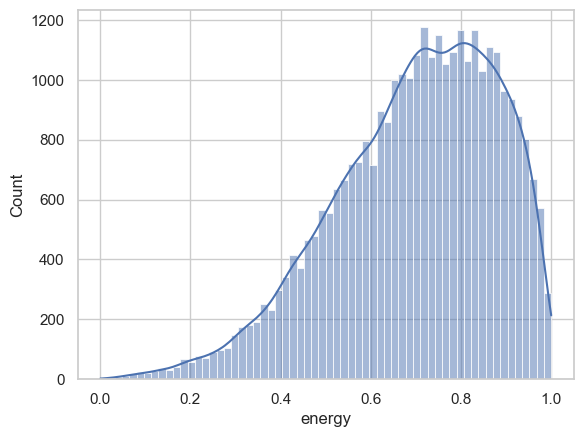

In [31]:
sns.histplot(data=spotify_df, x="energy", multiple='stack', kde=True)

plt.show()

The above graph shows the energy levels for the songs. It starts to grow noticeably around 0.4/5, which could mean that this dataset could be comrpised of mid/high energy tracks.

Categorical vs Categorial (Tempo vs Mood)

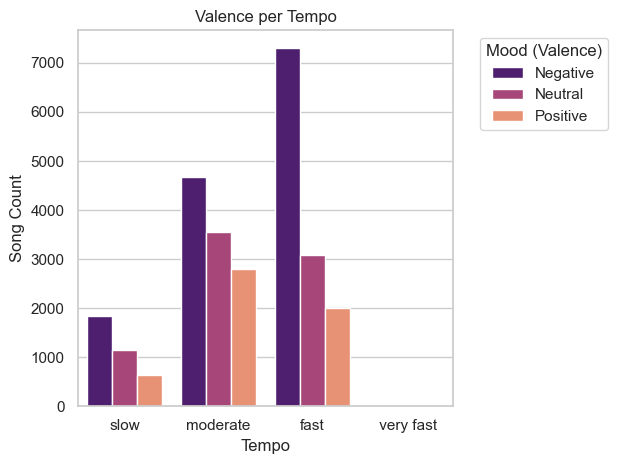

In [32]:
sns.set_theme(style='whitegrid')

sns.countplot(data=spotify_df, x='tempo_categorical', hue='valence_cat', order=['slow', 'moderate', 'fast', ' very fast'], palette='magma')
plt.title('Valence per Tempo')
plt.xlabel('Tempo')
plt.ylabel('Song Count')
plt.legend(title='Mood (Valence)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This graph shoes that most of the low valence have a fast tempo, with it being over 7000. Which indicates that a faster tempo =/= happy/high valence music and slower =/= sad/low valence. Very fast seems to have no bars, which could be an oversight on my part since it returns an empty data frame. (Seen with the below code.)

In [33]:
spotify_df[['tempo_categorical'] == 'very fast']

KeyError: False

Categorial to Continous

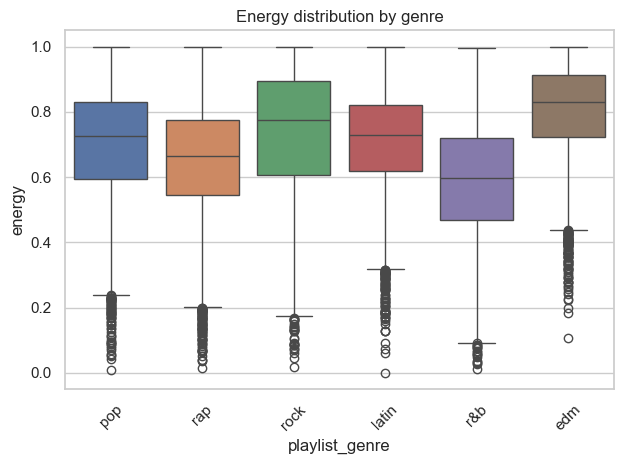

In [ ]:
sns.boxplot(data=spotify_df, x='playlist_genre', y='energy', hue='playlist_genre')
plt.title('Energy distribution by genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The above graph shows that EDM and rock are the genres with the highest energy, being over 0.8, while r&b is the lowest, dipping under 0.6. This confirms that this dataset has a bias for mid/high energy tracks.


 # Continous to continous

Comparing Danceability to Energy.

Text(0.5, 1.0, 'Density of Danceability vs Energy')

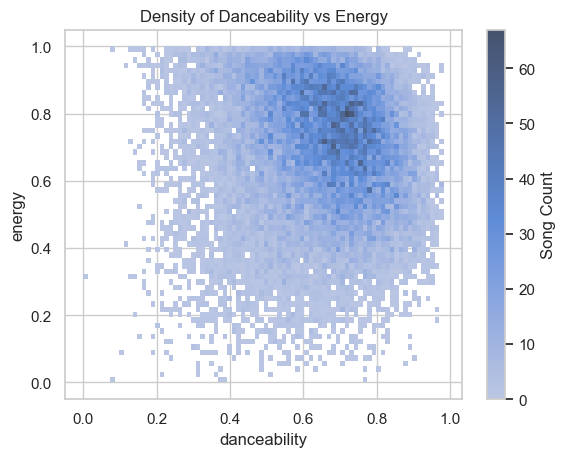

In [ ]:
sns.histplot(data=spotify_df, x='danceability', y='energy', cbar=True, cbar_kws={'label': 'Song Count'})
plt.title('Density of Danceability vs Energy')

The above graph shows that the density peaks in the upper right quandrant. The danceability varies across the graph, but the energy is consistent above 0.5. This confirms that this dataset could be biased towards mid/high-energy/danceability tracks.

# Relationships grouped by categorical variables

Playlist subgenre by danceability, using playlist_genre as the hue

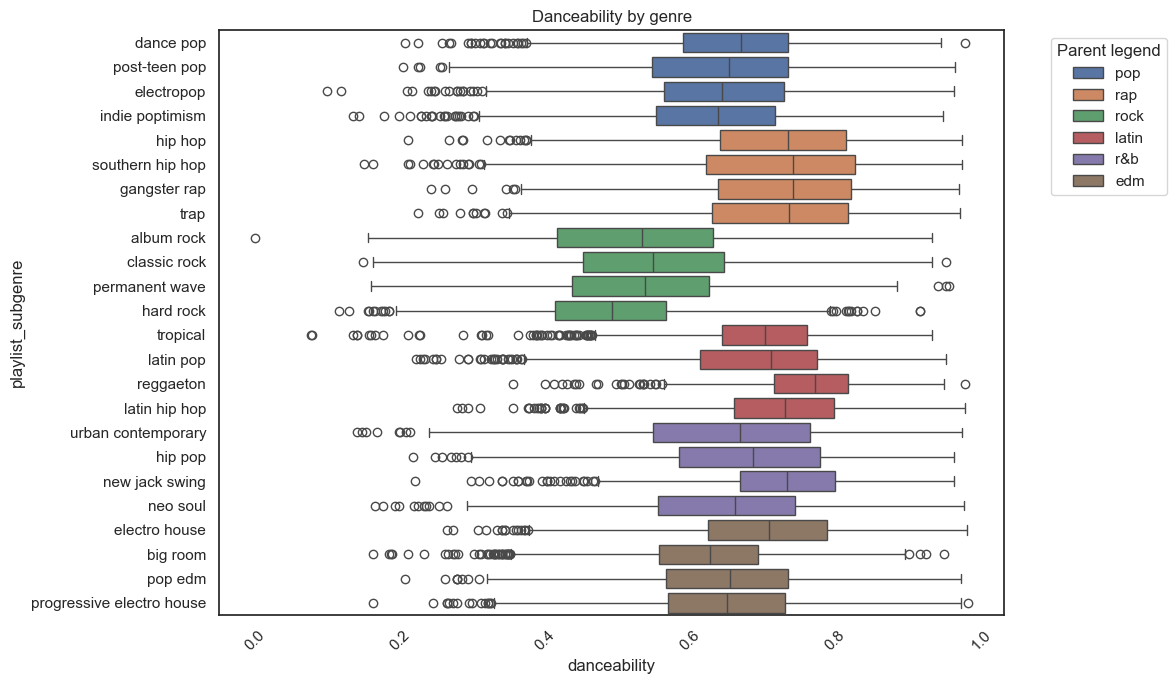

In [ ]:
sns.set_style('white')
plt.figure(figsize=(12,7))
sns.boxplot(data=spotify_df, y='playlist_subgenre', x='danceability', hue='playlist_genre')
plt.title('Danceability by genre')
plt.xticks(rotation=45)
plt.legend(title='Parent legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In this graph, we can tell that the rock genres (represented by the green boxes) are the least danceable genres being placed closest to the left. While the most danceable genre is the rap group (hip hop, southern hip hop, gangster rap, and trap, also represented by the orange boxes.). Since rock is the only genre that dips below 0.4, this could also infer that this dataset is biased towards mid to high danceability tracks, though there are some outliers going both ways.

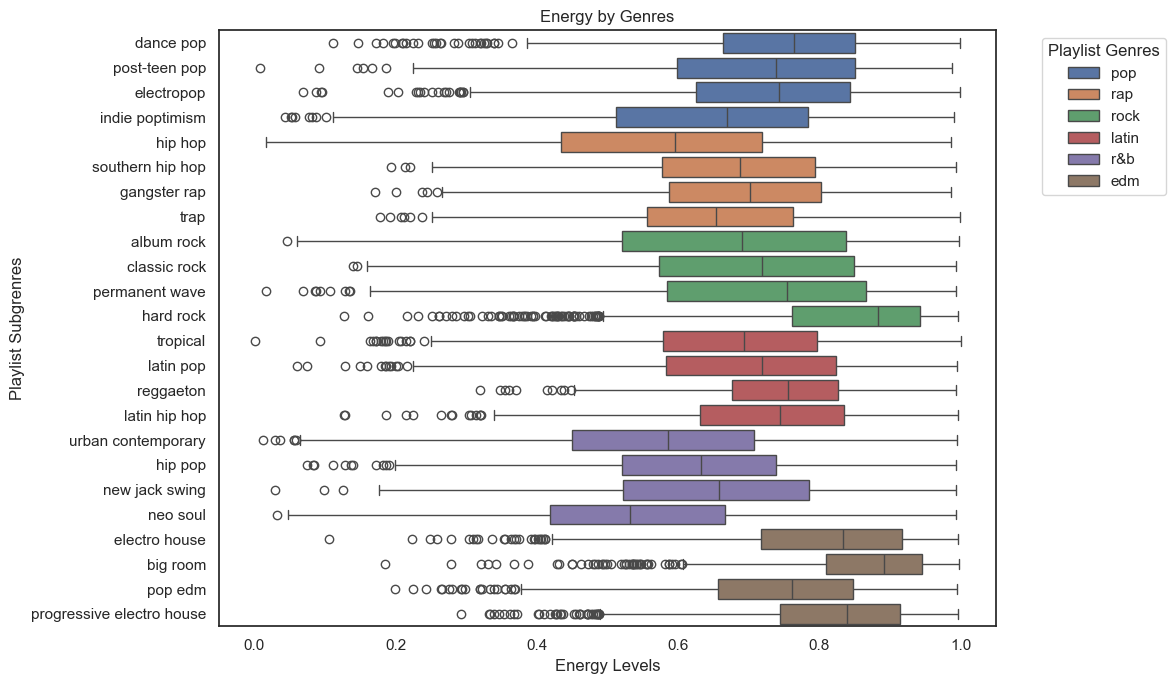

In [ ]:
plt.figure(figsize=(12,7))
sns.set_style('white')
sns.boxplot(data=spotify_df, y='playlist_subgenre', x='energy', hue='playlist_genre')

plt.title('Energy by Genres')
plt.xlabel('Energy Levels')
plt.ylabel('Playlist Subgrenres')
plt.legend(title='Playlist Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The above graph shows that neo soul is the only subgrenre to have a majority of its energy levels under 0.4. Dance Pop is mostly over 0.6 but has many outliers below 0.4 The rock genres seem to have mid/high energy levels but low danceability levels according the prior graph. 

## Comparing variables to track_popularity_transformed

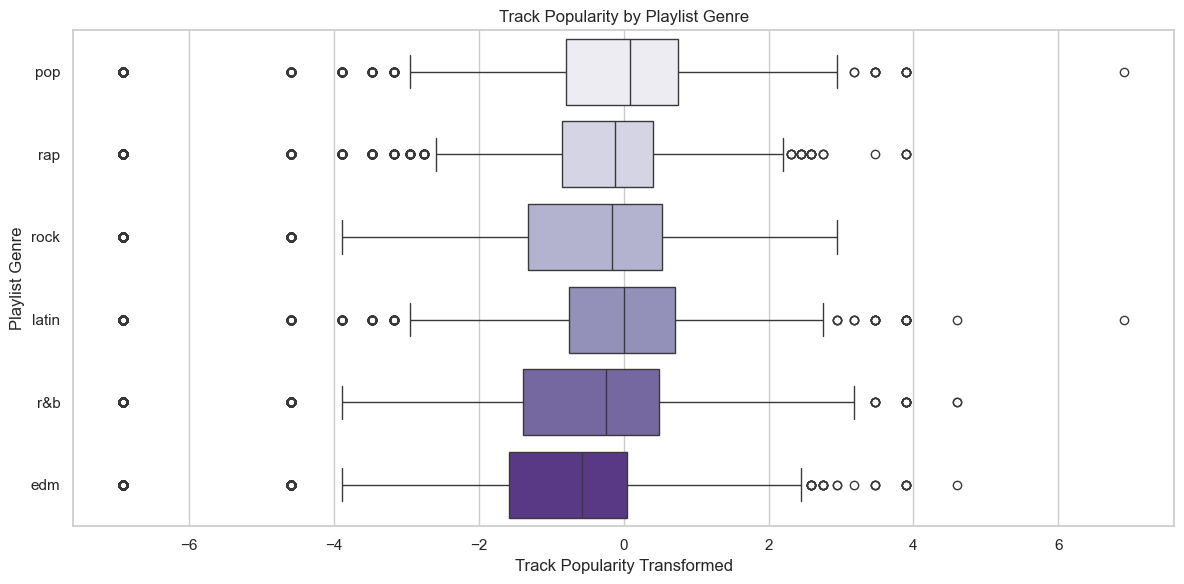

In [ ]:
plt.figure(figsize=(12,6))
sns.set_style('whitegrid')

sns.boxplot(data=spotify_df, x='track_popularity_transformed', y='playlist_genre', hue='playlist_genre', palette='Purples')

plt.title('Track Popularity by Playlist Genre')
plt.xlabel('Track Popularity Transformed')
plt.ylabel('Playlist Genre')
plt.tight_layout()
plt.show()

Pop is the most popular genre, with outliers going both directions. Latin also has a high outlier. Rock is the only genre that does not show any high outlier, which suggests a more rigid upper ceiling with its popular tracks.

Energy

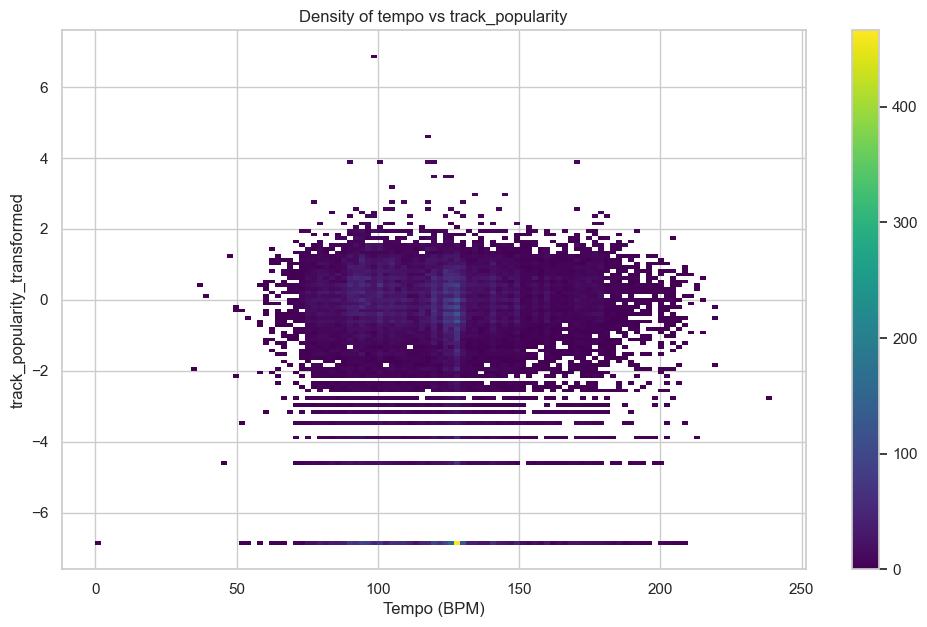

In [ ]:
plt.figure(figsize=(12,7))
sns.histplot(data=spotify_df, x='tempo', y='track_popularity_transformed', cbar=True, cmap='viridis')

plt.title('Density of tempo vs track_popularity')
plt.xlabel('Tempo (BPM)')
plt.show()

The above graph shows that while this dataset shows a strong preference for mid/high tempo tracks, it may not be a determining predictor of track popularity. Most of the popular and the obscure tracks are around the 100 - 120 BPM range. 

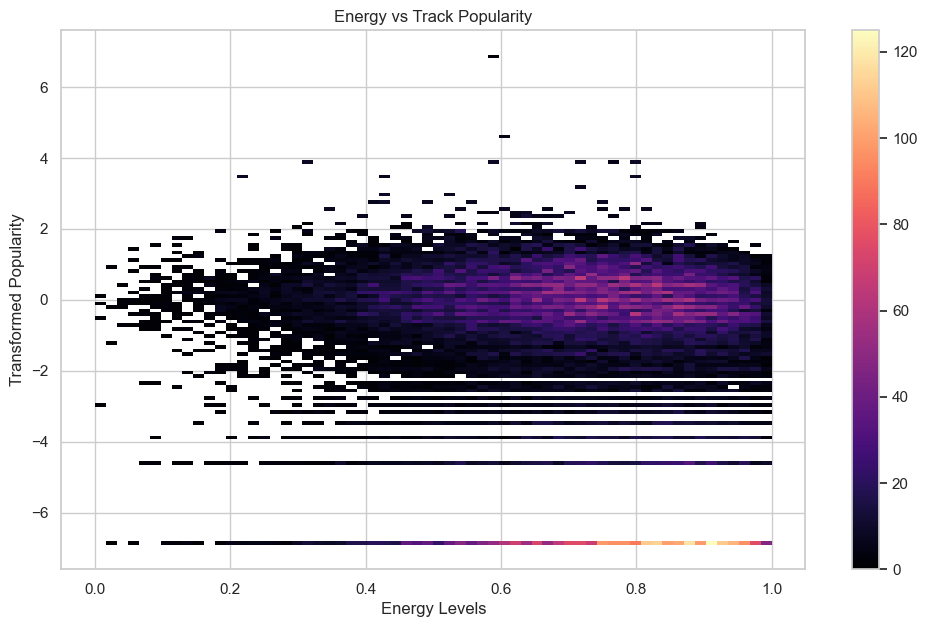

In [ ]:
plt.figure(figsize=(12,7))
sns.set_style('whitegrid')
sns.histplot(data=spotify_df, y='track_popularity_transformed', x='energy', cbar=True, cmap='magma')

plt.title('Energy vs Track Popularity')
plt.xlabel('Energy Levels')
plt.ylabel('Transformed Popularity')
plt.show()

The energy levels start to cluster heavily around 0.4 and remain consistent until 1.0. The most popular tracks seem to be in the 0.6 - 0.9 range. High energy songs seem to be a characteristic of this dataset as per my other observations, which could influence track popularity.

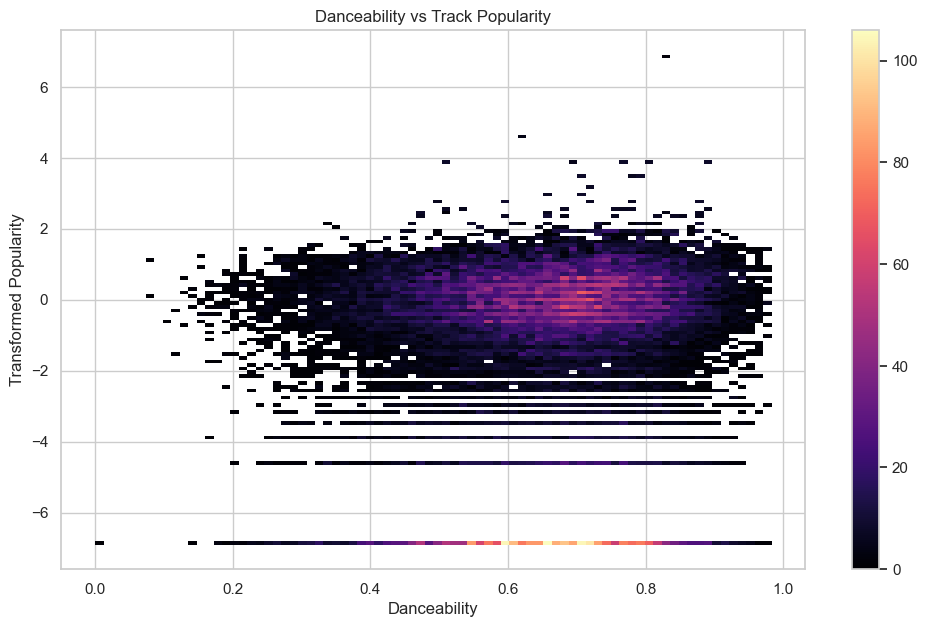

In [ ]:
plt.figure(figsize=(12,7))
sns.set_style('whitegrid')
sns.histplot(data=spotify_df, y='track_popularity_transformed', x='danceability', cbar=True, cmap='magma')

plt.title('Danceability vs Track Popularity')
plt.xlabel('Danceability')
plt.ylabel('Transformed Popularity')
plt.show()

The density peaks around 0.5 to 0.8, which means that most of the popular tracks are danceable and is therefore a contributor to track popularity.

# Findings and Discussion

I used heatmaps to help identify the relationships between song popularity and my converted categorical variables. Visually seeing the clusters/hotspots made it easier to make observations. Box plots made it easier to see visible outliers for the relationships group by categorical variables. Another observation that I can is that energy and danceability give similar results for genres, but they are not entirely the same due to outliers.

External sources used: 
pandas.cut (https://pandas.pydata.org/docs/reference/api/pandas.cut.html) - to convert the continous variables into categorical
